In [1]:
# Import models from script folder
import sys
import os

# Add project root to Python path
sys.path.append(os.path.abspath('..')) # This is to ensure the path gets found correctly

import script.data_preprocessing as dp
import script.data_visualization as dv
import script.data_modeling as dm
import script.feature_engineering as fe

## Load in the data
Load in the data and convert it to a dataframe for both the different folders with data, data1 and data2.

In [2]:
df_data1 = dp.load_data()
print(df_data1.shape)

(332920, 8)


In [3]:
df_data1.head()

,Flow rate (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Temperature TS outlet (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean)
Elapsed_seconds,,,,,,,,
0.00,2006.990755,0.663001,1.006496,1.122522,-6.231957,-6.344172,-6.309016,25.589479
0.05,2006.802163,0.666047,1.010171,1.129320,-6.287087,-6.373047,-6.327391,25.573727
0.10,2006.990755,0.666782,1.016682,1.137956,-6.245083,-6.338922,-6.322141,25.592105
0.15,2005.764905,0.662791,1.010171,1.127850,-6.255584,-6.370422,-6.324766,25.584228
0.20,2005.576313,0.663421,1.014057,1.130607,-6.247708,-6.375672,-6.322141,25.589479


In [4]:
df_data1.columns

Index(['Flow rate (Mean)', 'TS outlet pressure (Mean)',
       'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)',
       'Temperature TS outlet (Mean)', 'Tank temperature (Mean)',
       'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)'],
      dtype='object')

## Data exploration
Gain insights from the data by statistical descriptions, and visualizations.

In [5]:
df_data1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 332920 entries, 0.0 to 16645.95
Data columns (total 8 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Flow rate (Mean)              332920 non-null  float64
 1   TS outlet pressure (Mean)     332920 non-null  float64
 2   TS inlet pressure (Mean)      332920 non-null  float64
 3   Pump outlet pressure (Mean)   332920 non-null  float64
 4   Temperature TS outlet (Mean)  332920 non-null  float64
 5   Tank temperature (Mean)       332920 non-null  float64
 6   Temperature TS inlet (Mean)   332920 non-null  float64
 7   Bypass temperature (Mean)     332920 non-null  float64
dtypes: float64(8)
memory usage: 22.9 MB


In [6]:
df_data1.describe(include="all")

,Flow rate (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Temperature TS outlet (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean)
count,332920.000000,332920.000000,332920.000000,332920.000000,332920.000000,332920.000000,332920.000000,332920.000000
mean,452.227461,0.133907,0.165985,0.209865,-1.334454,-2.813034,-1.985317,25.272541
std,412.308971,0.136493,0.218570,0.237410,0.907439,0.407862,0.729935,0.477710
min,-2.366252,0.036422,0.037689,0.075172,-6.336966,-6.488546,-6.414019,24.565547
25%,349.264152,0.095646,0.106260,0.145547,-1.713938,-2.863448,-2.190256,24.914734
50%,363.691466,0.097327,0.107940,0.146833,-1.280776,-2.755824,-2.048501,25.174656
75%,380.098999,0.099427,0.109935,0.148303,-0.894867,-2.653450,-1.838494,25.450330
max,2013.025710,0.717080,1.031803,1.141999,1.066179,-2.086454,0.694713,26.571404


In [7]:
df_data1.isnull().sum()

Flow rate (Mean)                0
TS outlet pressure (Mean)       0
TS inlet pressure (Mean)        0
Pump outlet pressure (Mean)     0
Temperature TS outlet (Mean)    0
Tank temperature (Mean)         0
Temperature TS inlet (Mean)     0
Bypass temperature (Mean)       0
dtype: int64

In [8]:
df_data1.duplicated().sum()

np.int64(0)

## Sort values based on timestamp

In [9]:
df_data1 = dp.sort_values_by_timestamp(df_data1)
df_data1.head(5)

,Flow rate (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Temperature TS outlet (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean)
Elapsed_seconds,,,,,,,,
0.00,2006.990755,0.663001,1.006496,1.122522,-6.231957,-6.344172,-6.309016,25.589479
0.05,2006.802163,0.666047,1.010171,1.129320,-6.287087,-6.373047,-6.327391,25.573727
0.10,2006.990755,0.666782,1.016682,1.137956,-6.245083,-6.338922,-6.322141,25.592105
0.15,2005.764905,0.662791,1.010171,1.127850,-6.255584,-6.370422,-6.324766,25.584228
0.20,2005.576313,0.663421,1.014057,1.130607,-6.247708,-6.375672,-6.322141,25.589479


## Data visualization

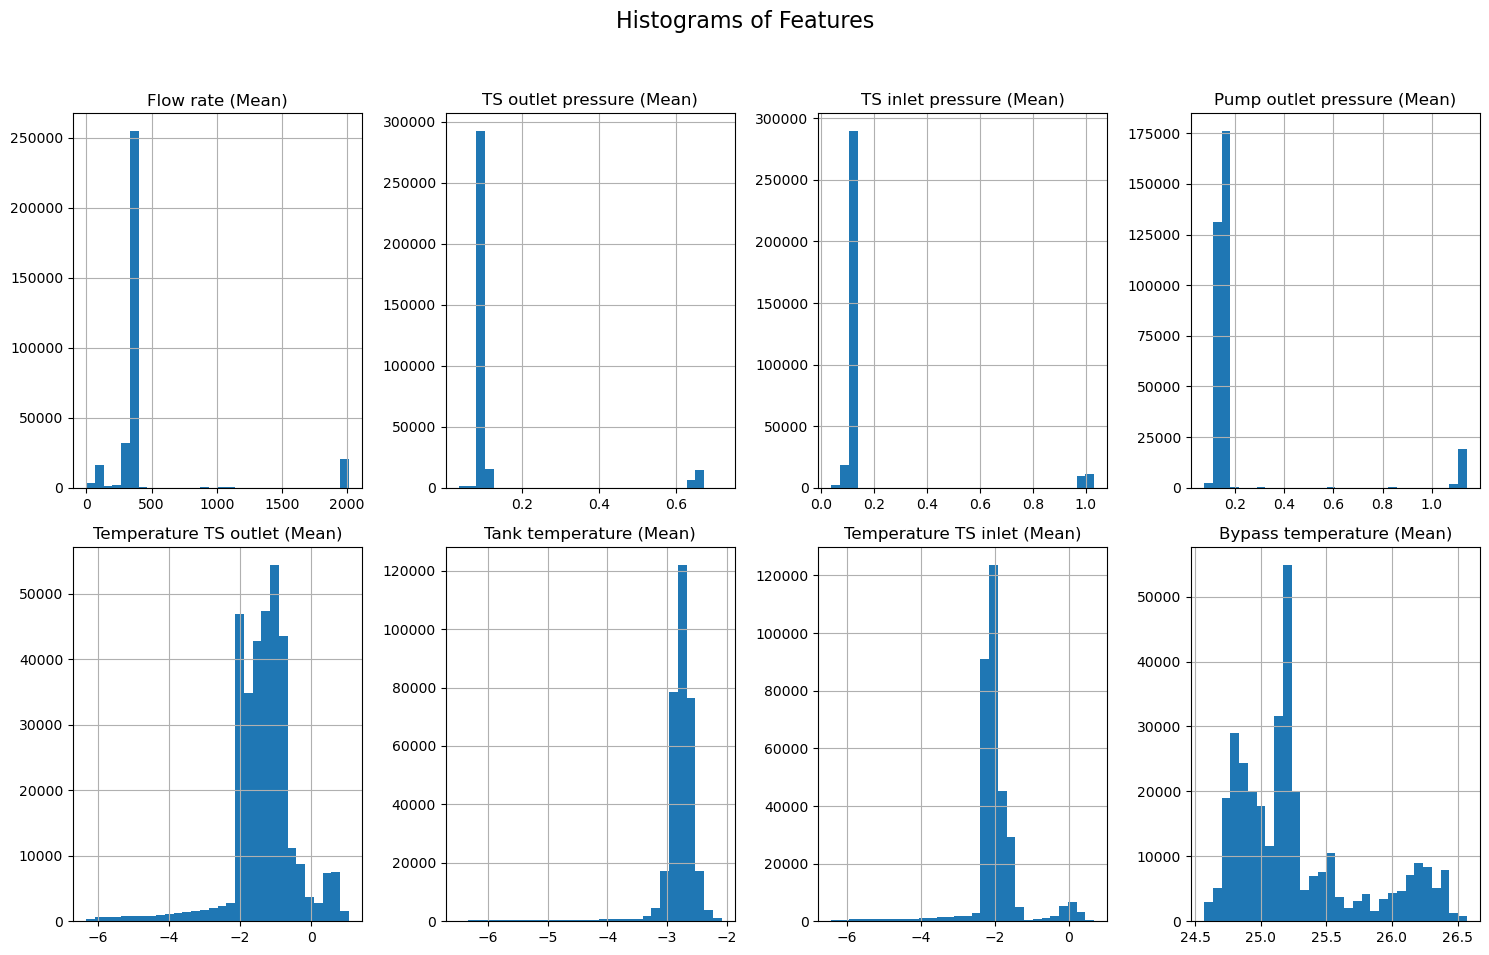

In [10]:
dv.plot_feature_histograms(df_data1)

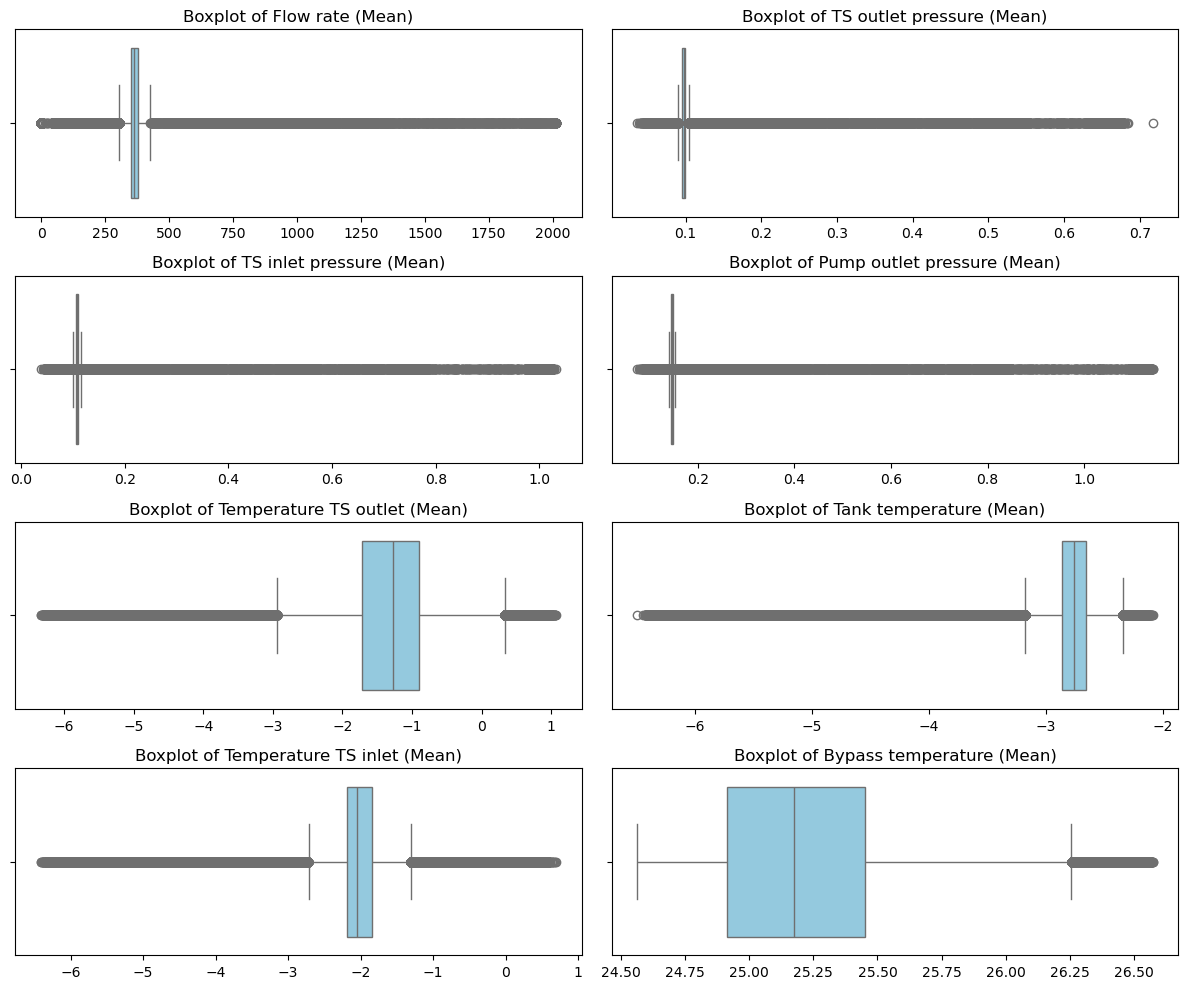

In [11]:
dv.plot_feature_boxplots(df_data1)

In [12]:
df_data1.head(3)

,Flow rate (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Temperature TS outlet (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean)
Elapsed_seconds,,,,,,,,
0.00,2006.990755,0.663001,1.006496,1.122522,-6.231957,-6.344172,-6.309016,25.589479
0.05,2006.802163,0.666047,1.010171,1.129320,-6.287087,-6.373047,-6.327391,25.573727
0.10,2006.990755,0.666782,1.016682,1.137956,-6.245083,-6.338922,-6.322141,25.592105


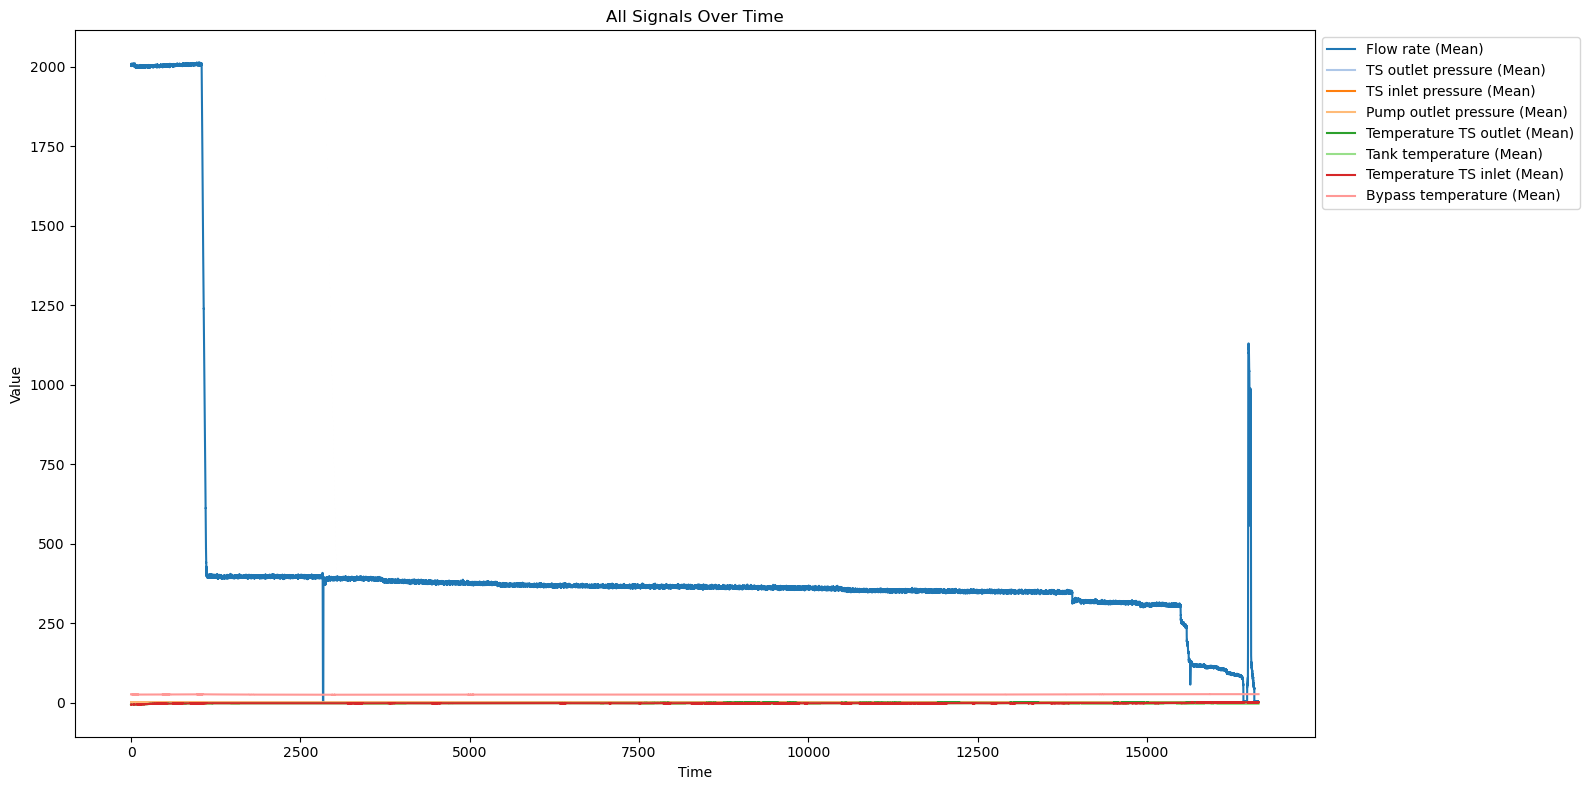

In [13]:
dv.plot_flow_pressure_drop_temp(df_data1)

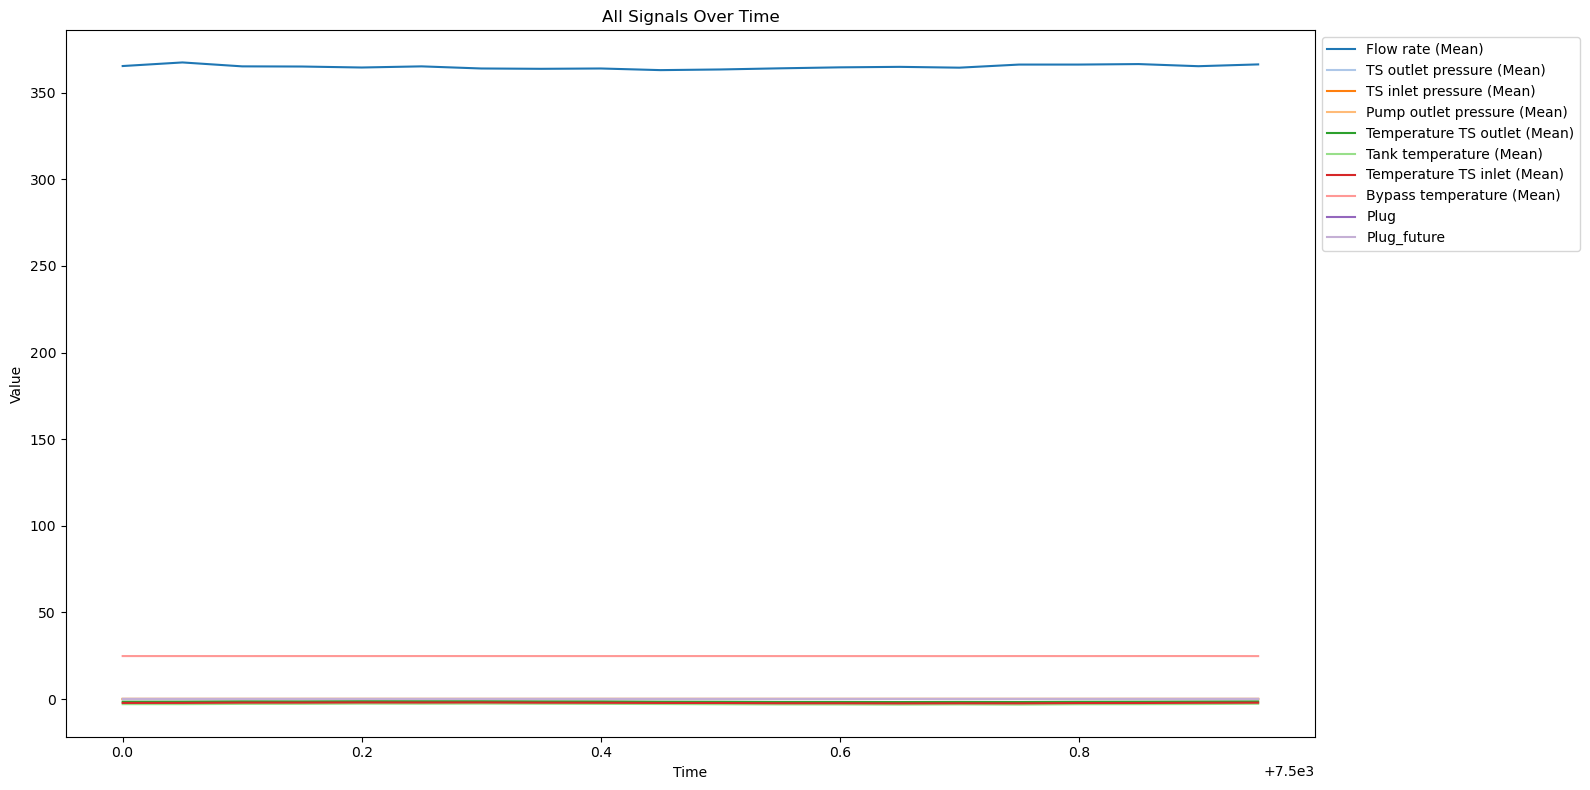

In [44]:
# visualize smaller time frame
dv.plot_flow_pressure_drop_temp(df_data1, start_time="7500", end_time="7501")

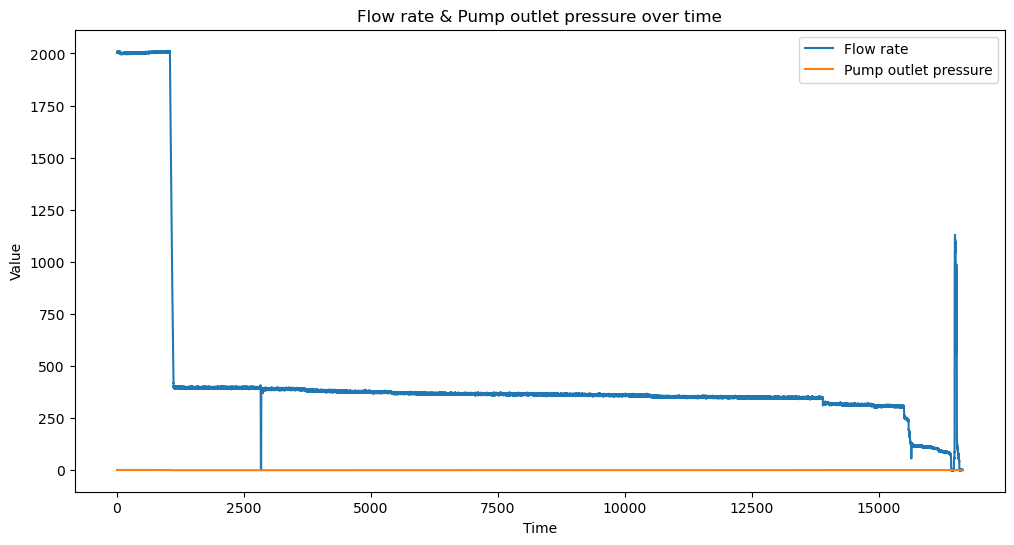

In [15]:
dv.visualize_flow_rate(df_data1)

### Make a target column for the dataframe
This target column is set based on a treshhold (supervised learning).
Another way to do this would be with anomaly detection, (unsupervised learning).

In [16]:
dp.create_target_column(df_data1)

In [17]:
df_data1.head(3)

,Flow rate (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Temperature TS outlet (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Plug
Elapsed_seconds,,,,,,,,,
0.00,2006.990755,0.663001,1.006496,1.122522,-6.231957,-6.344172,-6.309016,25.589479,1
0.05,2006.802163,0.666047,1.010171,1.129320,-6.287087,-6.373047,-6.327391,25.573727,1
0.10,2006.990755,0.666782,1.016682,1.137956,-6.245083,-6.338922,-6.322141,25.592105,1


In [18]:
# find a row with plug value of 1
plug_row = df_data1[df_data1["Plug"] == 1]
plug_row.head(1)

,Flow rate (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Temperature TS outlet (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Plug
Elapsed_seconds,,,,,,,,,
0.0,2006.990755,0.663001,1.006496,1.122522,-6.231957,-6.344172,-6.309016,25.589479,1


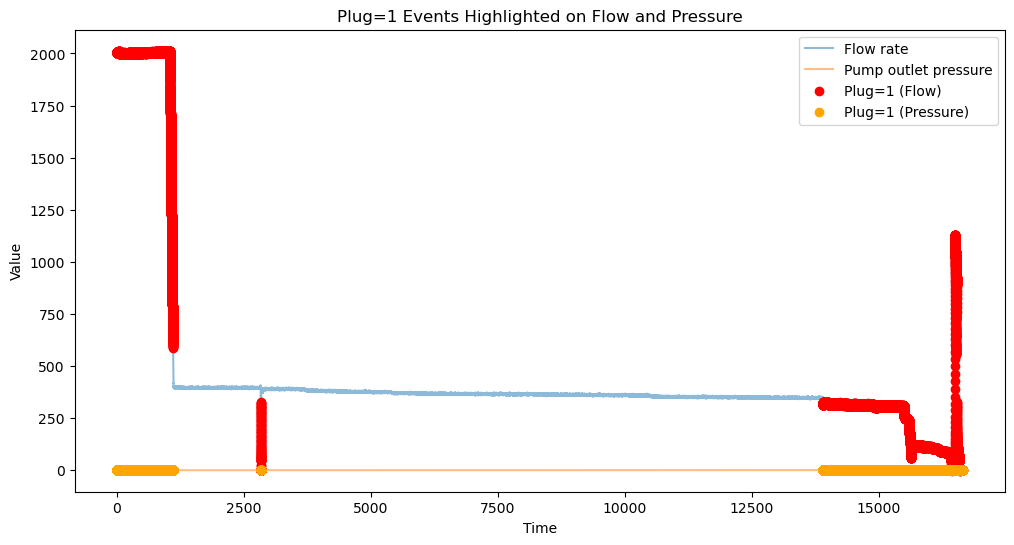

In [19]:
dv.visualize_plug_event(df_data1)

### Split the data into training and test

In [20]:
dp.create_future_target(df_data1)
df_data1.head(3)

,Flow rate (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Temperature TS outlet (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Plug,Plug_future
Elapsed_seconds,,,,,,,,,,
0.00,2006.990755,0.663001,1.006496,1.122522,-6.231957,-6.344172,-6.309016,25.589479,1,1.0
0.05,2006.802163,0.666047,1.010171,1.129320,-6.287087,-6.373047,-6.327391,25.573727,1,1.0
0.10,2006.990755,0.666782,1.016682,1.137956,-6.245083,-6.338922,-6.322141,25.592105,1,1.0


In [21]:
# Chronological split (no shuffle)
X_train, X_val, X_test, y_train, y_val, y_test = dp.split_data(df_data1)
X_train.head(3)

y shape : (332910,)
y shape after split: (329747,) (1581,) (1582,)


,Flow rate (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Temperature TS outlet (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean)
Elapsed_seconds,,,,,,,,
0.00,2006.990755,0.663001,1.006496,1.122522,-6.231957,-6.344172,-6.309016,25.589479
0.05,2006.802163,0.666047,1.010171,1.129320,-6.287087,-6.373047,-6.327391,25.573727
0.10,2006.990755,0.666782,1.016682,1.137956,-6.245083,-6.338922,-6.322141,25.592105


In [22]:
# Check class balance in each split
print("Train set: \n", y_train.value_counts())
print("Validation set: \n", y_val.value_counts())
print("Test set: \n", y_test.value_counts())

Train set: 
 Plug_future
0.0    255721
1.0     74026
Name: count, dtype: int64
Validation set: 
 Plug_future
1.0    1539
0.0      42
Name: count, dtype: int64
Test set: 
 Plug_future
1.0    1582
Name: count, dtype: int64


In [23]:
X_train.head(3)

,Flow rate (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Temperature TS outlet (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean)
Elapsed_seconds,,,,,,,,
0.00,2006.990755,0.663001,1.006496,1.122522,-6.231957,-6.344172,-6.309016,25.589479
0.05,2006.802163,0.666047,1.010171,1.129320,-6.287087,-6.373047,-6.327391,25.573727
0.10,2006.990755,0.666782,1.016682,1.137956,-6.245083,-6.338922,-6.322141,25.592105


### Feature engineering

In [24]:
X_train = fe.rolling_features(X_train)
X_val = fe.rolling_features(X_val)
X_test = fe.rolling_features(X_test)

X_train.head(3)

/Users/karolinagil/Documents/Master/script/feature_engineering.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_rolling[col_name] = getattr(rolling, func)().fillna(method='bfill')
/Users/karolinagil/Documents/Master/script/feature_engineering.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_rolling[col_name] = getattr(rolling, func)().fillna(method='bfill')
/Users/karolinagil/Documents/Master/script/feature_engineering.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_rolling[col_name] = getattr(rolling, func)().fillna(method='bfill')
/Users/karolinagil/Documents/Master/script/feature_engineering.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.f

,Flow rate (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Temperature TS outlet (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Flow rate (Mean)_rolling_mean_10,Flow rate (Mean)_rolling_std_10,...,Tank temperature (Mean)_rolling_min_10,Tank temperature (Mean)_rolling_max_10,Temperature TS inlet (Mean)_rolling_mean_10,Temperature TS inlet (Mean)_rolling_std_10,Temperature TS inlet (Mean)_rolling_min_10,Temperature TS inlet (Mean)_rolling_max_10,Bypass temperature (Mean)_rolling_mean_10,Bypass temperature (Mean)_rolling_std_10,Bypass temperature (Mean)_rolling_min_10,Bypass temperature (Mean)_rolling_max_10
Elapsed_seconds,,,,,,,,,,,,,,,,,,,,,
0.00,2006.990755,0.663001,1.006496,1.122522,-6.231957,-6.344172,-6.309016,25.589479,2006.990755,0.133355,...,-6.344172,-6.344172,-6.309016,0.012993,-6.309016,-6.309016,25.589479,0.011138,25.589479,25.589479
0.05,2006.802163,0.666047,1.010171,1.129320,-6.287087,-6.373047,-6.327391,25.573727,2006.896459,0.133355,...,-6.373047,-6.344172,-6.318204,0.012993,-6.327391,-6.309016,25.581603,0.011138,25.573727,25.589479
0.10,2006.990755,0.666782,1.016682,1.137956,-6.245083,-6.338922,-6.322141,25.592105,2006.927891,0.108884,...,-6.373047,-6.338922,-6.319516,0.009465,-6.327391,-6.309016,25.585104,0.009940,25.573727,25.592105


In [25]:
X_train.isna().sum()

Flow rate (Mean)                                0
TS outlet pressure (Mean)                       0
TS inlet pressure (Mean)                        0
Pump outlet pressure (Mean)                     0
Temperature TS outlet (Mean)                    0
Tank temperature (Mean)                         0
Temperature TS inlet (Mean)                     0
Bypass temperature (Mean)                       0
Flow rate (Mean)_rolling_mean_10                0
Flow rate (Mean)_rolling_std_10                 0
Flow rate (Mean)_rolling_min_10                 0
Flow rate (Mean)_rolling_max_10                 0
TS outlet pressure (Mean)_rolling_mean_10       0
TS outlet pressure (Mean)_rolling_std_10        0
TS outlet pressure (Mean)_rolling_min_10        0
TS outlet pressure (Mean)_rolling_max_10        0
TS inlet pressure (Mean)_rolling_mean_10        0
TS inlet pressure (Mean)_rolling_std_10         0
TS inlet pressure (Mean)_rolling_min_10         0
TS inlet pressure (Mean)_rolling_max_10         0


In [26]:
len(X_train.columns.tolist())

40

## Scale features

In [27]:
X_train, X_val, X_test = dp.scale_features(X_train, X_val, X_test)

⚙️ Features scaled using StandardScaler


In [28]:
X_train.head(3)

,Flow rate (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Temperature TS outlet (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Flow rate (Mean)_rolling_mean_10,Flow rate (Mean)_rolling_std_10,...,Tank temperature (Mean)_rolling_min_10,Tank temperature (Mean)_rolling_max_10,Temperature TS inlet (Mean)_rolling_mean_10,Temperature TS inlet (Mean)_rolling_std_10,Temperature TS inlet (Mean)_rolling_min_10,Temperature TS inlet (Mean)_rolling_max_10,Bypass temperature (Mean)_rolling_mean_10,Bypass temperature (Mean)_rolling_std_10,Bypass temperature (Mean)_rolling_min_10,Bypass temperature (Mean)_rolling_max_10
Elapsed_seconds,,,,,,,,,,,,,,,,,,,,,
0.00,3.769735,3.891036,3.855507,3.851978,-5.461369,-8.634564,-6.094472,0.705783,3.769339,-1.474697,...,-8.551901,-8.910197,-6.131227,-1.341737,-6.132574,-6.102468,0.706074,-0.150213,0.746822,0.665663
0.05,3.769277,3.913425,3.872355,3.880656,-5.523070,-8.705175,-6.120487,0.671932,3.769110,-1.474697,...,-8.624067,-8.910197,-6.144313,-1.341737,-6.159397,-6.102468,0.689142,-0.150213,0.712944,0.665663
0.10,3.769735,3.918827,3.902206,3.917088,-5.476060,-8.621725,-6.113054,0.711426,3.769186,-1.521096,...,-8.624067,-8.897344,-6.146183,-1.423712,-6.159397,-6.102468,0.696668,-0.399507,0.712944,0.671305


In [29]:
X_train.tail(3)

,Flow rate (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Temperature TS outlet (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Flow rate (Mean)_rolling_mean_10,Flow rate (Mean)_rolling_std_10,...,Tank temperature (Mean)_rolling_min_10,Tank temperature (Mean)_rolling_max_10,Temperature TS inlet (Mean)_rolling_mean_10,Temperature TS inlet (Mean)_rolling_std_10,Temperature TS inlet (Mean)_rolling_min_10,Temperature TS inlet (Mean)_rolling_max_10,Bypass temperature (Mean)_rolling_mean_10,Bypass temperature (Mean)_rolling_std_10,Bypass temperature (Mean)_rolling_min_10,Bypass temperature (Mean)_rolling_max_10
Elapsed_seconds,,,,,,,,,,,,,,,,,,,,,
16487.20,-0.936765,1.756185,1.025255,1.043616,2.180611,-1.303873,3.078041,2.466124,-0.943589,1.228896,...,-1.335433,-0.858262,3.256827,1.020121,3.251969,3.253086,2.478371,1.005757,2.463387,2.481837
16487.25,-0.934247,1.783197,1.033438,1.067645,2.142416,-1.348805,3.059459,2.443555,-0.942308,1.844332,...,-1.335433,-0.858262,3.219436,0.905974,3.251969,3.253086,2.480629,0.677331,2.485974,2.481837
16487.30,-0.934934,1.828738,1.076767,1.105625,2.227620,-1.246100,3.144940,2.415345,-0.941278,2.167545,...,-1.335433,-1.044619,3.186533,0.370479,3.251969,3.158585,2.477807,1.104033,2.457741,2.481837


## Save datasets

In [30]:
# save data
dp.save_data(X_train, X_val, X_test, y_train, y_val, y_test, 'dataset1')

# Dataset 2

In [31]:
df_data2 = dp.load_data("../data/raw_data/data2/*.csv")
print(df_data2.shape)
df_data2.columns

(2046277, 8)


Index(['Flow rate (Mean)', 'TS outlet pressure (Mean)',
       'TS inlet pressure (Mean)', 'Pump outlet pressure (Mean)',
       'Temperature TS outlet (Mean)', 'Tank temperature (Mean)',
       'Temperature TS inlet (Mean)', 'Bypass temperature (Mean)'],
      dtype='object')

In [32]:
df_data2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2046277 entries, 0.0 to 20462.76
Data columns (total 8 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   Flow rate (Mean)              float64
 1   TS outlet pressure (Mean)     float64
 2   TS inlet pressure (Mean)      float64
 3   Pump outlet pressure (Mean)   float64
 4   Temperature TS outlet (Mean)  float64
 5   Tank temperature (Mean)       float64
 6   Temperature TS inlet (Mean)   float64
 7   Bypass temperature (Mean)     float64
dtypes: float64(8)
memory usage: 140.5 MB


In [33]:
df_data2.describe(include="all")

,Flow rate (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Temperature TS outlet (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean)
count,2.046277e+06,2.046277e+06,2.046277e+06,2.046277e+06,2.046277e+06,2.046277e+06,2.046277e+06,2.046277e+06
mean,4.277005e+02,1.237998e-01,1.453959e-01,1.922374e-01,-4.462725e-01,-2.632296e+00,-6.490695e-01,2.461759e+01
std,2.364495e+02,7.511268e-02,1.200806e-01,1.299952e-01,5.067265e-01,1.980324e-01,5.661325e-01,4.406262e-01
min,3.669918e+02,9.627600e-02,1.088850e-01,1.536320e-01,-4.032015e+00,-4.514561e+00,-4.382203e+00,2.376215e+01
25%,3.820792e+02,1.083520e-01,1.220110e-01,1.683310e-01,-6.585970e-01,-2.742699e+00,-9.433400e-01,2.411659e+01
50%,3.853796e+02,1.109770e-01,1.251610e-01,1.701690e-01,-3.698210e-01,-2.624575e+00,-5.495770e-01,2.486485e+01
75%,3.948092e+02,1.141280e-01,1.283120e-01,1.729250e-01,-1.598030e-01,-2.506451e+00,-2.739430e-01,2.500925e+01
max,1.876673e+03,6.139630e-01,9.132490e-01,1.072359e+00,5.621350e-01,-1.942080e+00,7.629660e-01,2.528493e+01


In [34]:
df_data2.isnull().sum()

Flow rate (Mean)                0
TS outlet pressure (Mean)       0
TS inlet pressure (Mean)        0
Pump outlet pressure (Mean)     0
Temperature TS outlet (Mean)    0
Tank temperature (Mean)         0
Temperature TS inlet (Mean)     0
Bypass temperature (Mean)       0
dtype: int64

In [35]:
df_data2.duplicated().sum()

np.int64(21)

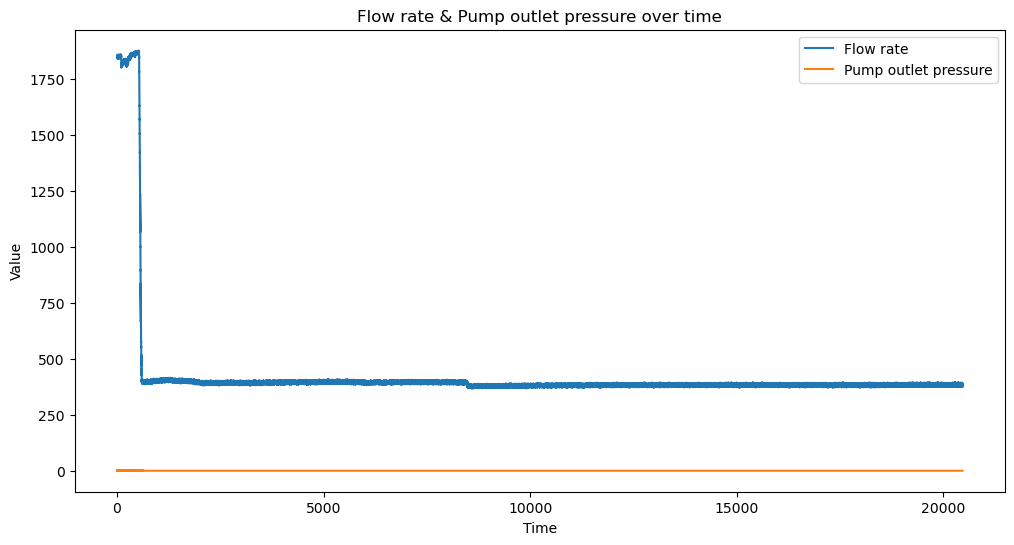

In [36]:
dv.visualize_flow_rate(df_data2)

In [37]:
dp.create_target_column(df_data2)

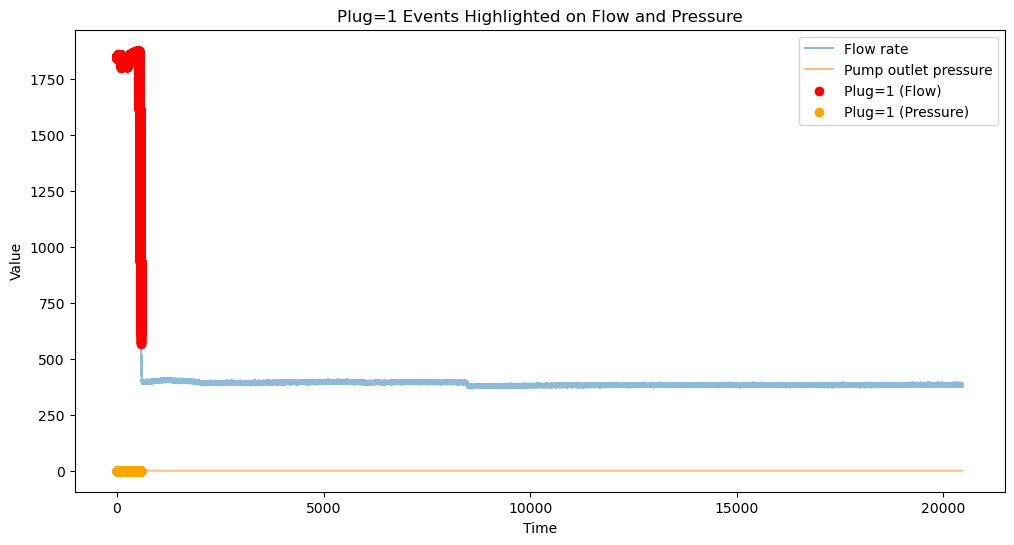

In [38]:
dv.visualize_plug_event(df_data2)

In [39]:
dp.create_future_target(df_data2)

In [40]:
df_data2

,Flow rate (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Temperature TS outlet (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean),Plug,Plug_future
Elapsed_seconds,,,,,,,,,,
0.00,1848.384604,0.587711,0.883321,0.920769,-3.861375,-4.160188,-3.962189,24.195356,1,1.0
0.01,1849.799046,0.586661,0.885422,1.039285,-3.940132,-4.448936,-4.211572,24.234738,1,1.0
0.02,1850.270527,0.584561,0.888572,0.986918,-3.861375,-4.120814,-3.830935,24.221611,1,1.0
0.03,1850.742008,0.586661,0.882271,0.963031,-3.992637,-4.448936,-4.132819,24.195356,1,1.0
0.04,1850.742008,0.583511,0.874396,1.031935,-3.848249,-4.199563,-3.975314,24.287248,1,1.0
...,...,...,...,...,...,...,...,...,...,...
20462.62,383.493661,0.103627,0.115711,0.164656,-0.172929,-2.624575,-0.168940,24.090338,0,0.0
20462.63,384.436622,0.113078,0.123586,0.167413,-0.238560,-2.624575,-0.168940,24.129720,0,0.0
20462.64,382.079218,0.108352,0.121486,0.167413,-0.172929,-2.703324,-0.208316,24.064083,0,0.0


In [41]:
X_train2, X_val2, X_test2, y_train2, y_val2, y_test2 = dp.split_data(df_data2)
model2 = dm.train_and_evaluate_rf(X_train2, X_val2, y_train2, y_val2)

y shape : (2046267,)
y shape after split: (2026827,) (9720,) (9720,)
Validation F1 Score: 1.000
